# Step 0: 라이브러리 설치 및 데이터 로드


In [82]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [83]:
# 과제 1에서 저장한 데이터 로드
df = pd.read_csv("..\과제1\wikipedia_text_dataset.csv")

df.head()

,title,content,references,clean_text,tokens
0,"Enfield, County Meath","\n Enfield (Irish: An Bóthar Buí, meaning 'the...","\n^ a b ""Census 2022 - F1015 Population"". Cent...",\n enfield irish an b thar bu meaning the...,"['enfield', 'irish', 'thar', 'meaning', 'yello..."
1,Viktor Lowenfeld,Austrian Viktor Lowenfeld (1903–1960) was an A...,"\n^ Douglas C. Allen. ""United States of Americ...",austrian viktor lowenfeld was an a...,"['austrian', 'viktor', 'lowenfeld', 'austrian'..."
2,Yugoslav Olympic Committee,The Yugoslav Olympic Committee (Croatian: Jugo...,"\n^ ""JOK postao Olimpijski komitet Srbije i Cr...",the yugoslav olympic committee croatian jugo...,"['yugoslav', 'olympic', 'committee', 'croatian..."
3,József Sátori,\n József Sátori (25 February 1926 – 23 Februa...,"\n^ a b Evans, Hilary; Gjerde, Arild; Heijmans...",\n j zsef s tori february februa...,"['zsef', 'tori', 'february', 'february', 'hung..."
4,Luang Prabang montane rain forests,The Luang Prabang montane rain forests ecoregi...,"\n^ a b ""Luang Prabang montane rain forests"". ...",the luang prabang montane rain forests ecoregi...,"['luang', 'prabang', 'montane', 'rain', 'fores..."


# Step 1: 데이터 확인

In [84]:
print("총 문서 수:", len(df))
print("컬럼 목록:", df.columns.tolist())
print("\n첫 번째 문서 샘플:")
print(df["clean_text"][0][:500])

총 문서 수: 100
컬럼 목록: ['title', 'content', 'references', 'clean_text', 'tokens']

첫 번째 문서 샘플:

 enfield  irish  an b thar bu   meaning  the yellow road    also known as innfield    is a town in south county meath  ireland  situated between kilcock and kinnegad and very close to the border with county kildare  the town is on the dublin sligo railway line  it is located on the r    regional road   formerly the n  national primary road connecting dublin to connacht 
 in the    years between the      and      census  the population of enfield grew considerably from just     inhabitants to   


# Step 2: TF-IDF 벡터화

🔍 TF-IDF란?

- **TF (Term Frequency)**: 특정 단어가 문서 내에서 등장하는 빈도
- **IDF (Inverse Document Frequency)**: 특정 단어가 전체 문서에서 얼마나 희귀한지

👉 TF-IDF = TF × IDF
👉 자주 등장하지만 특정 문서에만 있는 단어일수록 높은 값

In [116]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TfidfVectorizer 객체 생성
vectorizer = TfidfVectorizer(
    max_features = 5000,  # 👈 최대 단어 수 (예: 1000, 5000)
    stop_words = "english"     # 👈 불용어 설정 (예: "english")
)

# TF-IDF 행렬 생성
tfidf_matrix = vectorizer.fit_transform(df["clean_text"])  # 👈 어떤 컬럼을 사용할까요?

print("TF-IDF 행렬 크기:", tfidf_matrix.shape)  # 👈 shape 확인

TF-IDF 행렬 크기: (100, 5000)


In [117]:
# 단어 목록 확인
feature_names = vectorizer.get_feature_names_out()

print("총 단어 수:", len(feature_names))
print("단어 예시:", feature_names[:20])

총 단어 수: 5000
단어 예시: ['aaron' 'aayan' 'ab' 'abandoned' 'abc' 'abctv' 'abdicate' 'abdicated'
 'abdication' 'abdomen' 'abdulaigermany' 'abel' 'abilities' 'ability'
 'able' 'absence' 'academia' 'academic' 'academy' 'accelerate']


In [118]:
# 특정 문서의 TF-IDF 상위 단어 확인
doc_index = 0  # 첫 번째 문서

# 해당 문서의 TF-IDF 벡터
tfidf_scores = tfidf_matrix[doc_index].toarray().flatten()

# 상위 10개 단어 추출
top_indices = tfidf_scores.argsort()[-10:]  # 👈 상위 10개를 가져오려면?
top_words = [(feature_names[i], tfidf_scores[i]) for i in top_indices]

print(f"문서 '{df['title'][doc_index]}'의 TF-IDF 상위 단어:")
for word, score in reversed(top_words):
    print(f"  {word}: {score:.4f}")

문서 'Enfield, County Meath'의 TF-IDF 상위 단어:
  enfield: 0.5317
  dublin: 0.3818
  canal: 0.2312
  road: 0.2068
  town: 0.1589
  mullingar: 0.1387
  railway: 0.1317
  opened: 0.1192
  trains: 0.1192
  route: 0.1156


# Step 3: 코사인 유사도 이해

🔍 코사인 유사도란?

두 벡터 간의 각도를 이용해 유사도를 측정

- 값 범위: 0 ~ 1
- 1에 가까울수록 유사함
- 0에 가까울수록 관련 없음

공식: cos(θ) = (A · B) / (||A|| × ||B||)

In [119]:
from sklearn.metrics.pairwise import cosine_similarity

# 문서 간 유사도 행렬 계산
cosine_sim = cosine_similarity(tfidf_matrix)  # 👈 어떤 행렬을 넣을까요?

print("유사도 행렬 크기:", cosine_sim.shape)  # 👈 shape 확인

유사도 행렬 크기: (100, 100)


In [120]:
# 첫 번째 문서와 가장 유사한 문서 찾기
doc_index = 0
sim_scores = cosine_sim[doc_index]

# 자기 자신 제외하고 가장 유사한 문서 인덱스
sim_scores[doc_index] = -1  # 자기 자신 제외
most_similar_idx = sim_scores.argmax()  # 👈 가장 큰 값의 인덱스?

print(f"'{df['title'][doc_index]}'와 가장 유사한 문서:")
print(f"  → '{df['title'][most_similar_idx]}' (유사도: {sim_scores[most_similar_idx]:.4f})")

'Enfield, County Meath'와 가장 유사한 문서:
  → 'Wendlingen (Neckar) station' (유사도: 0.1269)


# Step 4: 검색 함수 구현

In [121]:
def search(query, top_k=5):
    """
    쿼리와 가장 유사한 문서 Top-K 반환
    """
    # 1. 쿼리를 TF-IDF 벡터로 변환
    query_vec = vectorizer.transform([query])  # 👈 새로운 텍스트를 벡터로 변환하는 함수?

    # 2. 쿼리와 모든 문서 간 코사인 유사도 계산
    similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()  # 👈 어떤 행렬과 비교?

    # 3. 유사도 높은 순으로 정렬
    top_indices = similarities.argsort()[-top_k:][::-1]  # 👈 상위 k개?

    # 4. 결과 반환
    results = []
    for idx in top_indices:
        results.append({
            "title": df["title"][idx],
            "score": similarities[idx],
            "content": df["clean_text"][idx][:200] + "..."
        })

    return results

In [122]:
# 검색 테스트
query = "machine learning algorithm"

results = search(query, top_k=5)  # 👈 몇 개의 결과를 볼까요?

print(f"🔍 검색어: '{query}'\n")
for i, r in enumerate(results, 1):
    print(f"{i}. {r['title']} (유사도: {r['score']:.4f})")
    print(f"   {r['content']}\n")

🔍 검색어: 'machine learning algorithm'

1. Datascope Analytics (유사도: 0.1247)
   datascope analytics was an american data driven consulting and design firm based in chicago  illinois   the firm was founded in      by co founders mike stringer and dean malmgren after the two realiz...

2. Great Books (TV program) (유사도: 0.1219)
   
 great books is an hour long documentary and biography program that aired on the learning channel  the series was a project co created by walter cronkite and television producer jonathan ward under a...

3. Great Peace Shipping Ltd v Tsavliris (International) Ltd (유사도: 0.0179)
   
 great peace shipping ltd v tsavliris  international  ltd   ewca civ       also known as the great peace  is a case in english contract law which investigates when a common mistake within a contractu...

4. Tchê Tchê (유사도: 0.0000)
   
 danilo das neves pinheiro  born    august        known by his nickname tch  tch   is a brazilian professional footballer who plays as defensive midfielder

# Step 5: 다양한 쿼리 테스트

In [123]:
# 여러 쿼리로 테스트해보세요
queries = [
    "university",  # 👈 테스트할 쿼리 1
    "korea",  # 👈 테스트할 쿼리 2
    "big data"   # 👈 테스트할 쿼리 3
]

for query in queries:
    print("=" * 60)
    print(f"🔍 검색어: '{query}'")
    print("=" * 60)

    results = search(query, top_k=3)

    for i, r in enumerate(results, 1):
        print(f"{i}. {r['title']} (유사도: {r['score']:.4f})")
    print()

🔍 검색어: 'university'
1. Edmund Copeland (유사도: 0.1691)
2. Kylie Louw (유사도: 0.1282)
3. Datascope Analytics (유사도: 0.1240)

🔍 검색어: 'korea'
1. Andre Lee (유사도: 0.1844)
2. Tchê Tchê (유사도: 0.0000)
3. John Clarke (satirist) (유사도: 0.0000)

🔍 검색어: 'big data'
1. Datascope Analytics (유사도: 0.4023)
2. Black Bob (musician) (유사도: 0.0364)
3. Heroes (American TV series) (유사도: 0.0140)



# Step 6: 유사도 히트맵 시각화


In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

# 시각화를 위해 상위 10개 문서만 선택
n_docs = 10
cosine_sim_subset = cosine_sim[:n_docs, :n_docs]
titles_subset = df["title"][:n_docs].tolist()

# 제목이 너무 길면 자르기
titles_short = [t[:15] + "..." if len(t) > 15 else t for t in titles_subset]

In [125]:
# 한글 포트 사용을 위한 코드
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

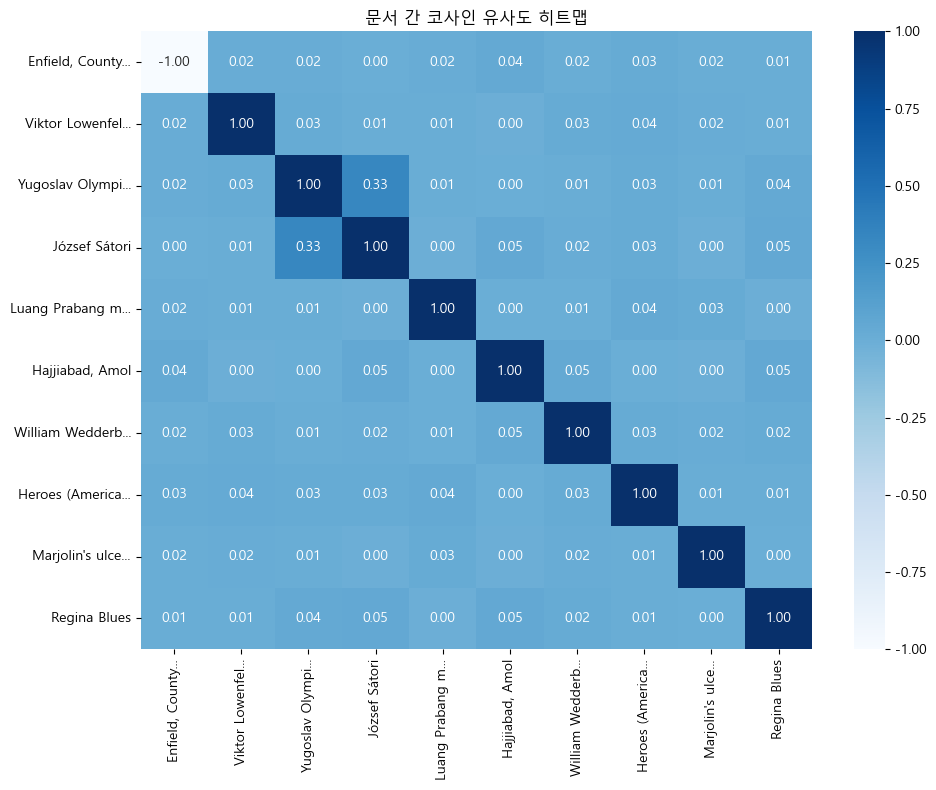

In [128]:
# 히트맵 시각화
plt.figure(figsize=(10, 8))  # 👈 그래프 크기 설정

sns.heatmap(
    cosine_sim_subset,           # 👈 어떤 데이터를 시각화?
    annot=True,         # 숫자 표시
    fmt=".2f",          # 소수점 2자리
    cmap="Blues",    # 👈 컬러맵 (예: "Blues", "YlOrRd", "coolwarm")
    xticklabels=titles_short,
    yticklabels=titles_short
)

plt.title("문서 간 코사인 유사도 히트맵")
plt.tight_layout()
plt.show()

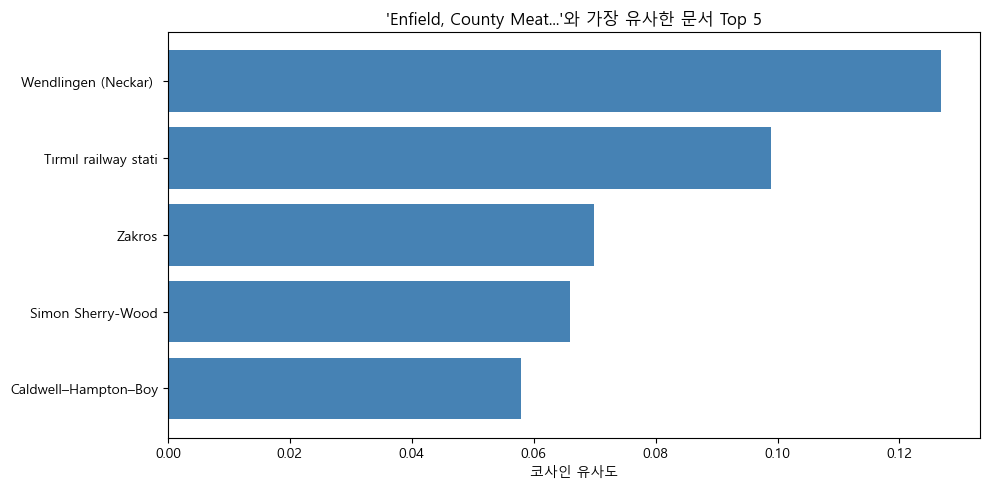

In [134]:
# 특정 문서와 다른 문서들의 유사도 막대그래프
doc_index = 0
similarities = cosine_sim[doc_index].copy()
similarities[doc_index] = 0  # 자기 자신 제외

# 상위 5개 유사 문서
top_k = 5
top_indices = similarities.argsort()[-top_k:]  # 👈 상위 5개 가져오기

top_titles = [df["title"][i][:20] for i in top_indices]
top_scores = [similarities[i] for i in top_indices]

plt.figure(figsize=(10, 5))
plt.barh(top_titles, top_scores, color="steelblue")  # 👈 x축, y축 데이터
plt.xlabel("코사인 유사도")
plt.title(f"'{df['title'][doc_index][:20]}...'와 가장 유사한 문서 Top 5")
plt.tight_layout()
plt.show()

In [135]:
def analyze_similarity_contribution(idx1, idx2, tfidf_matrix, feature_names, top_n=10):
    # 1. 두 문서의 TF-IDF 벡터 추출 (sparse matrix를 dense array로 변환)
    vec1 = tfidf_matrix[idx1].toarray().flatten()
    vec2 = tfidf_matrix[idx2].toarray().flatten()

    # 2. 요소별 곱셈 (Element-wise product) 수행
    # 두 문서 모두에서 점수가 높을수록 이 값이 커집니다.
    contribution = vec1 * vec2

    # 3. 기여도가 높은 순으로 정렬
    top_indices = contribution.argsort()[::-1][:top_n]

    # 4. 결과 정리
    results = []
    for i in top_indices:
        if contribution[i] > 0: # 기여도가 0보다 큰 경우만 포함
            results.append({
                "word": feature_names[i],
                "contribution": contribution[i],
                "tfidf_doc1": vec1[i],
                "tfidf_doc2": vec2[i]
            })

    return pd.DataFrame(results)

In [141]:
# --- 실행 예시 ---
idx1, idx2 = doc_index, top_indices[-1]
word_cnt = 5
contributions_df = analyze_similarity_contribution(idx1, idx2, tfidf_matrix, feature_names, word_cnt)

print(f"📄 문서 1: {df['title'][idx1]}")
print(f"📄 문서 2: {df['title'][idx2]}")
print(f"🤝 코사인 유사도: {cosine_sim[idx1][idx2]:.4f}")
print(f"\n✨ 유사도에 가장 많이 기여한 단어 TOP {word_cnt}:")
print(contributions_df)

📄 문서 1: Enfield, County Meath
📄 문서 2: Wendlingen (Neckar) station
🤝 코사인 유사도: 0.1269

✨ 유사도에 가장 많이 기여한 단어 TOP 5:
      word  contribution  tfidf_doc1  tfidf_doc2
0  railway      0.042673    0.131689    0.324046
1  station      0.016662    0.053869    0.309296
2   trains      0.014559    0.119164    0.122178
3     town      0.011647    0.158885    0.073307
4     line      0.006532    0.094063    0.069438
